In [ ]:

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm import tqdm
import re
import matplotlib.pyplot as plt

class NetworkDatasetWithParams(Dataset):
    """Dataset that extracts parameters from filenames"""
    def __init__(self, data_dir):
        self.files = list(Path(data_dir).glob('*.npy'))
        
    def __len__(self):
        return len(self.files)
    
    def parse_params(self, filename):
        """Extract eta and gamma from filename"""
        # Pattern: net_eta3.0_gamma0.449999988079071_...
        # Match with or without hyphens after eta/gamma
        match = re.search(r'eta-?([\d.]+)_gamma-?([\d.]+)', str(filename))
        if match:
            eta = float(match.group(1))
            gamma = float(match.group(2))
            return np.array([eta, gamma], dtype=np.float32)
        else:
            raise ValueError(f"Cannot parse parameters from {filename}")
    
    def __getitem__(self, idx):
        filepath = self.files[idx]
        net = np.load(filepath)
        net = (net.reshape(-1) > 0).astype(np.float32)
        params = self.parse_params(filepath.name)
        return torch.from_numpy(net), torch.from_numpy(params)

class ParameterPredictor(nn.Module):
    """Network to predict generative parameters from adjacency matrix"""
    def __init__(self, input_dim=10000, n_params=2, hidden_dims=[1024, 512, 256, 128]):
        super().__init__()
        
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(0.2)
            ])
            prev_dim = h_dim
        
        layers.append(nn.Linear(hidden_dims[-1], n_params))
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

def train_predictor(data_dir, epochs=100, batch_size=128, lr=1e-3):
    device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
    
    # Load dataset with parameters
    dataset = NetworkDatasetWithParams(data_dir)
    
    # Split train/val
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(
        dataset, [train_size, val_size]
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    model = ParameterPredictor().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)
    criterion = nn.MSELoss()
    
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for networks, params in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            networks, params = networks.to(device), params.to(device)
            
            optimizer.zero_grad()
            pred_params = model(networks)
            loss = criterion(pred_params, params)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * networks.size(0)
        
        train_loss /= len(train_dataset)
        train_losses.append(train_loss)
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for networks, params in val_loader:
                networks, params = networks.to(device), params.to(device)
                pred_params = model(networks)
                loss = criterion(pred_params, params)
                val_loss += loss.item() * networks.size(0)
        
        val_loss /= len(val_dataset)
        val_losses.append(val_loss)
        scheduler.step(val_loss)
        
        print(f'Epoch {epoch+1}: Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'param_predictor_best.pth')
    
    # Plot training curves
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.title('Parameter Prediction Training')
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return model

def evaluate_predictions(model, data_dir):
    """Evaluate how well the model predicts parameters"""
    device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
    model.eval()
    
    dataset = NetworkDatasetWithParams(data_dir)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    
    all_true_params = []
    all_pred_params = []
    
    with torch.no_grad():
        for networks, params in loader:
            networks = networks.to(device)
            pred_params = model(networks)
            all_true_params.append(params.numpy())
            all_pred_params.append(pred_params.cpu().numpy())
    
    all_true_params = np.vstack(all_true_params)
    all_pred_params = np.vstack(all_pred_params)
    
    # Plot predictions vs true values
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    param_names = ['η (eta)', 'γ (gamma)']
    for i, (ax, name) in enumerate(zip(axes, param_names)):
        ax.scatter(all_true_params[:, i], all_pred_params[:, i], alpha=0.5, s=20)
        
        # Perfect prediction line
        min_val = min(all_true_params[:, i].min(), all_pred_params[:, i].min())
        max_val = max(all_true_params[:, i].max(), all_pred_params[:, i].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
        
        # Correlation
        corr = np.corrcoef(all_true_params[:, i], all_pred_params[:, i])[0, 1]
        mae = np.mean(np.abs(all_true_params[:, i] - all_pred_params[:, i]))
        
        ax.set_xlabel(f'True {name}')
        ax.set_ylabel(f'Predicted {name}')
        ax.set_title(f'{name}\nCorr: {corr:.4f}, MAE: {mae:.4f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('parameter_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nOverall prediction quality:")
    print(f"η correlation: {np.corrcoef(all_true_params[:, 0], all_pred_params[:, 0])[0, 1]:.4f}")
    print(f"γ correlation: {np.corrcoef(all_true_params[:, 1], all_pred_params[:, 1])[0, 1]:.4f}")
    
    return all_true_params, all_pred_params

# Usage
data_dir = '/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/02_test/generated_networks/'

# Train the predictor
model = train_predictor(data_dir, epochs=100, batch_size=128, lr=1e-3)

# Evaluate
true_params, pred_params = evaluate_predictions(model, data_dir)

# Save predictions
np.save('true_parameters.npy', true_params)
np.save('predicted_parameters.npy', pred_params)


Epoch 1/100:   0%|          | 0/1 [00:00<?, ?it/s]


ValueError: Cannot parse parameters from net_eta3.0_gamma0.449999988079071_ruleMatchingIndex_id002.npy

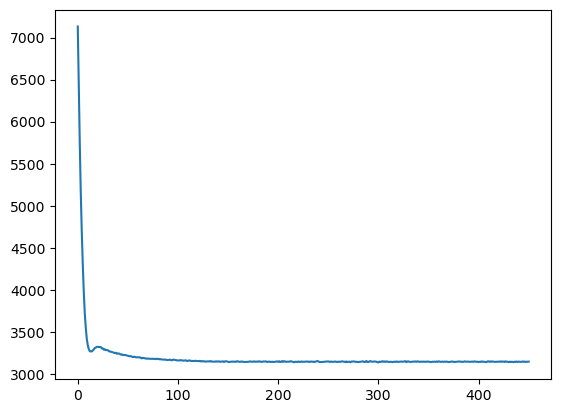

In [28]:
import matplotlib.pyplot as plt
plt.plot(loss_history)

In [29]:
# experiment_name = '05_second_big_overnight_run_10201'
# data_dir = f'/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/{experiment_name}/generated_networks/'

# model = train_vae(data_dir, epochs=20, batch_size=32, lr=1e-3, beta=1.0)

# # Save model
# torch.save(model.state_dict(), 'brain_vae.pth')



In [30]:

# # Encode networks to latent space
# model.eval()
# dataset = NetworkDataset(data_dir)
# latents = []
# with torch.no_grad():
#     for net in dataset:
#         mu, _ = model.encode(net.unsqueeze(0))
#         latents.append(mu.cpu().numpy())
# latents = np.vstack(latents)
# np.save('latent_representations.npy', latents)
# print(f'Latent shape: {latents.shape}')  # Should be (n_networks, 4)

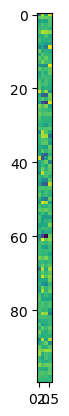

In [31]:
import matplotlib.pyplot as plt 
plt.imshow(latents[:100,:4])

In [32]:
# model.encode(net.unsqueeze(0))

In [33]:
# Get some reconstructions 


In [34]:
latents.shape

(126, 4)

Average MSE: 0.087718 ± 0.002231
Average Correlation: 0.1257 ± 0.0746
Sample 62 - Latent: [0.11686515 0.32792154 0.08369684 0.33013487]
Sample 32 - Latent: [-0.78621083  1.2235978   0.4044677  -0.1745623 ]
Sample 84 - Latent: [ 0.4747269  -0.46770114 -0.21799564  0.09980065]
Sample 121 - Latent: [0.5603516  0.2320128  0.5023155  0.24386023]
Sample 31 - Latent: [0.4336969  0.24524379 0.38392138 0.4715309 ]


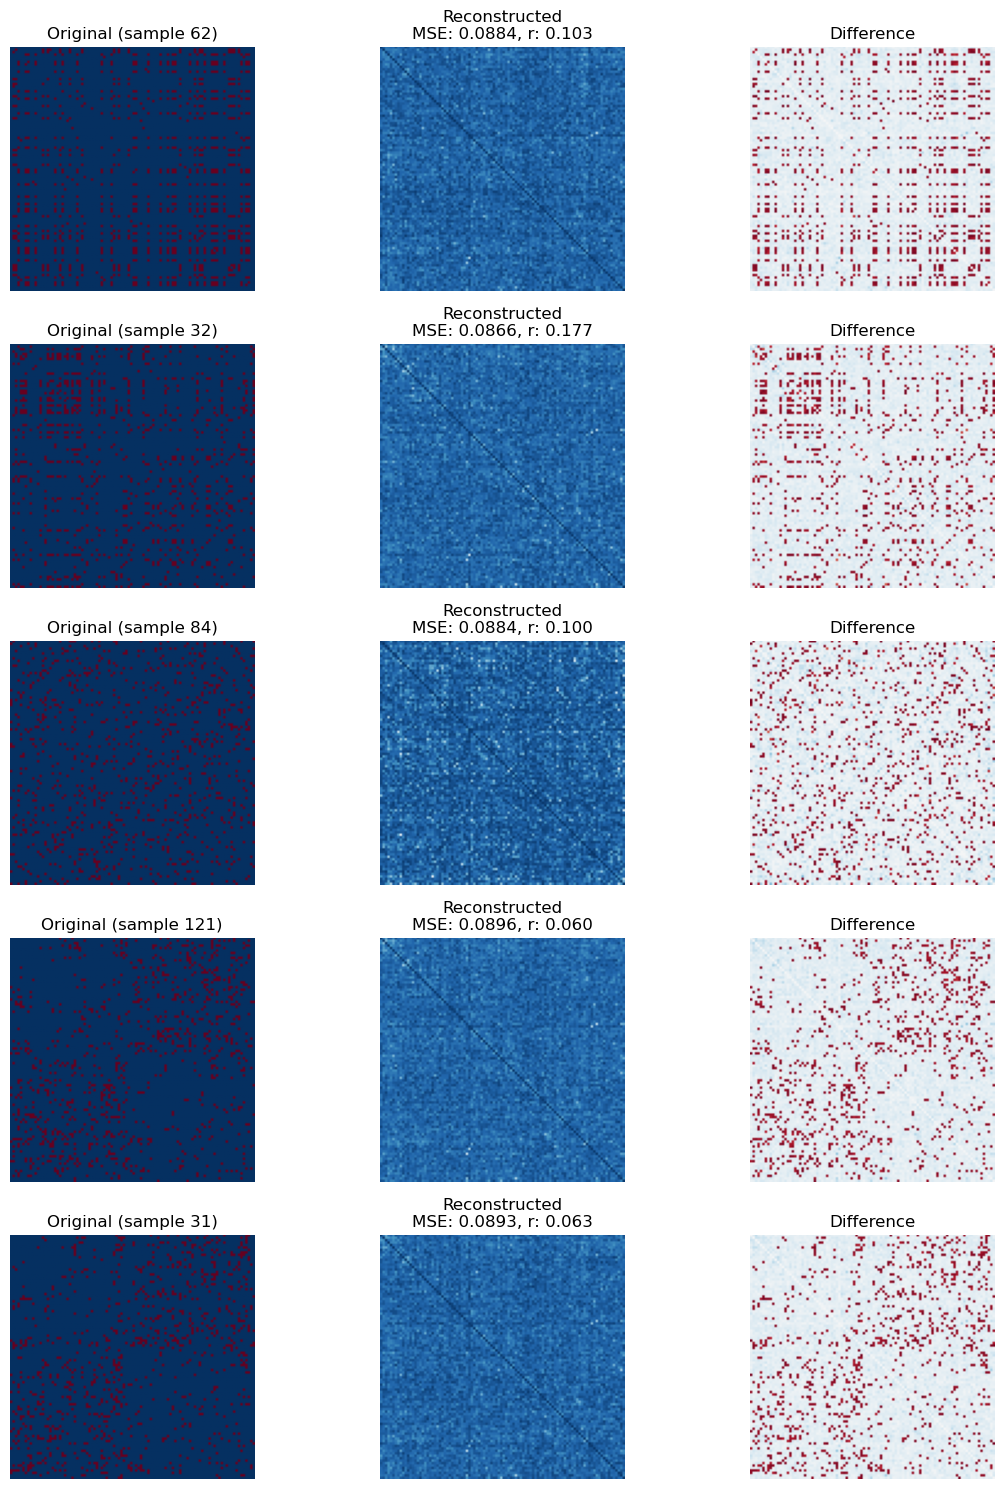

In [37]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
n_samples = 5

# Compute metrics on all data
mses = []
corrs = []

with torch.no_grad():
    for i in range(len(dataset)):
        original = dataset[i].to(device)
        recon, _, _ = model(original.unsqueeze(0))
        
        # MSE
        mse = torch.mean((original - recon.squeeze()) ** 2).item()
        mses.append(mse)
        
        # Correlation
        orig_np = original.cpu().numpy()
        recon_np = recon.squeeze().cpu().numpy()
        corr = np.corrcoef(orig_np, recon_np)[0, 1]
        corrs.append(corr)

print(f"Average MSE: {np.mean(mses):.6f} ± {np.std(mses):.6f}")
print(f"Average Correlation: {np.mean(corrs):.4f} ± {np.std(corrs):.4f}")

# Visualize a few examples
fig, axes = plt.subplots(n_samples, 3, figsize=(12, 3*n_samples))

indices = np.random.choice(len(dataset), n_samples, replace=False)

with torch.no_grad():
    for i, idx in enumerate(indices):
        original = dataset[idx].to(device)
        recon, mu, _ = model(original.unsqueeze(0))
        
        # Reshape to 100x100
        orig_matrix = original.cpu().numpy().reshape(100, 100)
        recon_matrix = recon.squeeze().cpu().numpy().reshape(100, 100)
        diff = orig_matrix - recon_matrix
        
        # Plot
        vmin, vmax = orig_matrix.min(), orig_matrix.max()
        
        axes[i, 0].imshow(orig_matrix, cmap='RdBu_r', vmin=vmin, vmax=vmax)
        axes[i, 0].set_title(f'Original (sample {idx})')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(recon_matrix, cmap='RdBu_r', vmin=vmin, vmax=vmax)
        axes[i, 1].set_title(f'Reconstructed\nMSE: {mses[idx]:.4f}, r: {corrs[idx]:.3f}')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        axes[i, 2].set_title('Difference')
        axes[i, 2].axis('off')
        
        print(f"Sample {idx} - Latent: {mu.cpu().numpy()[0]}")

plt.tight_layout()
# plt.savefig('vae_reconstruction_quality.png', dpi=150, bbox_inches='tight')
plt.show()


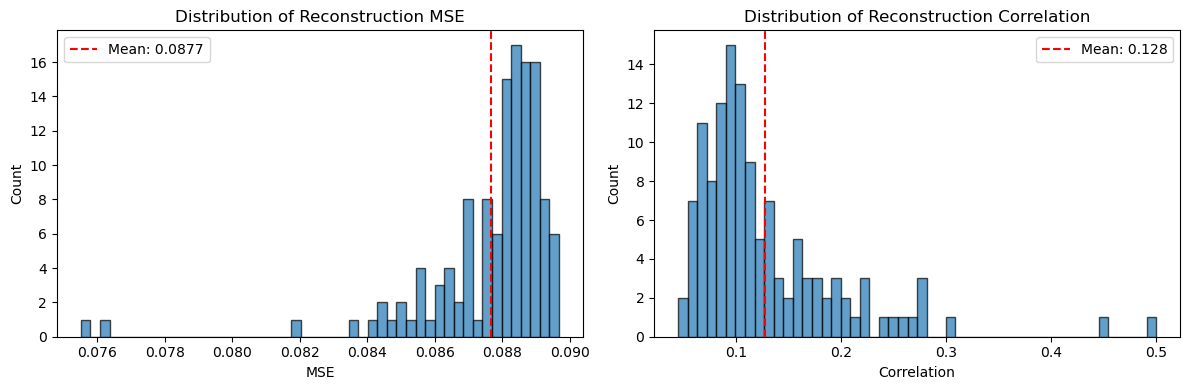

In [36]:

# Distribution of errors
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(mses, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('MSE')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Reconstruction MSE')
axes[0].axvline(np.mean(mses), color='red', linestyle='--', label=f'Mean: {np.mean(mses):.4f}')
axes[0].legend()

axes[1].hist(corrs, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Correlation')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Reconstruction Correlation')
axes[1].axvline(np.mean(corrs), color='red', linestyle='--', label=f'Mean: {np.mean(corrs):.3f}')
axes[1].legend()

plt.tight_layout()
# plt.savefig('vae_error_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

